Projeto: Análise de Avaliações de Clientes com API do ChatGPT

Integrantes:
- Mariana Okamoto - 10418069 - 10418069@mackenzista.com.br

Descrição:
Este notebook realiza a análise exploratória e preparação de dados do dataset que contém dados coletados das avaliações de clientes do 89ºC Coffee Station no Google Maps.

Histórico de alterações:
- 24/03/2026 – Criação do notebook e importação dos dados
- 24/03/2026 – Limpeza e tratamento de dados


Colunas que não possuiam informações relevantes foram excluídas. Valores ausentes nas colunas “Espera”, "Barulho" e "TipoRefeicao" foram tratados por meio da substituição por “Não informado”, para evitar perda de dados durante a análise.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset89coffee.csv", sep=";")
df.head()

,Nota,HaQuantoTempo,TipoRefeicao,Preco,Comentario,Comida,Serviço,Ambiente,Barulho,TamGrupo,Espera,PratosRecomendados,Estacionamento,Acessibilidade,Assento,Evento
0,4,3 semanas atrás,Café da manhã,R$ 40–60,"Fui hoje, domingo, por volta de 09h da manhã j...",5,3,4,Nível moderado de barulho,"1 pessoa, 2 pessoas",NaN,NaN,NaN,NaN,NaN,NaN
1,5,3 semanas atrás,Outro,R$ 20–40,"A comida é incrível, mas erraram no sabor da m...",5,4,4,"Nível muito alto de barulho, difícil de ouvir",2 pessoas,NaN,NaN,NaN,NaN,NaN,NaN
2,5,2 meses atrás,Outro,R$ 40–60,Incrível!!!Visitamos a 89 em uma sexta por vol...,5,5,5,NaN,De 3 a 4 pessoas,NaN,NaN,NaN,NaN,NaN,NaN
3,2,3 semanas atrás,Outro,R$ 40–60,"Vitrine lindaaa, você olha e quer comer tudooo...",2,4,4,Nível moderado de barulho,NaN,Sem espera,NaN,NaN,NaN,NaN,NaN
4,5,3 meses atrás,Café da manhã,R$ 80–100,"Meu lugar favorito da Liba, tem muita fila mas...",5,5,5,Nível moderado de barulho,NaN,De 10 a 30 min,NaN,NaN,NaN,NaN,NaN


In [55]:
len(df)
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Nota           136 non-null    int64 
 1   HaQuantoTempo  136 non-null    object
 2   TipoRefeicao   136 non-null    object
 3   Preco          136 non-null    object
 4   Comentario     136 non-null    object
 5   Comida         136 non-null    int64 
 6   Serviço        136 non-null    int64 
 7   Ambiente       136 non-null    int64 
 8   Barulho        136 non-null    object
 9   Espera         136 non-null    object
dtypes: int64(4), object(6)
memory usage: 10.8+ KB


,Nota,Comida,Serviço,Ambiente
count,136.000000,136.000000,136.000000,136.000000
mean,4.426471,4.580882,4.264706,4.264706
std,0.907845,0.915344,1.005432,0.888072
min,1.000000,1.000000,1.000000,1.000000
25%,4.000000,5.000000,4.000000,4.000000
50%,5.000000,5.000000,5.000000,4.000000
75%,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000


In [45]:
df = df.drop(columns=['TamGrupo', 'PratosRecomendados', 'Estacionamento', 'Acessibilidade', 'Assento', 'Evento'])
df.head()

,Nota,HaQuantoTempo,TipoRefeicao,Preco,Comentario,Comida,Serviço,Ambiente,Barulho,Espera
0,4,3 semanas atrás,Café da manhã,R$ 40–60,"Fui hoje, domingo, por volta de 09h da manhã j...",5,3,4,Nível moderado de barulho,NaN
1,5,3 semanas atrás,Outro,R$ 20–40,"A comida é incrível, mas erraram no sabor da m...",5,4,4,"Nível muito alto de barulho, difícil de ouvir",NaN
2,5,2 meses atrás,Outro,R$ 40–60,Incrível!!!Visitamos a 89 em uma sexta por vol...,5,5,5,NaN,NaN
3,2,3 semanas atrás,Outro,R$ 40–60,"Vitrine lindaaa, você olha e quer comer tudooo...",2,4,4,Nível moderado de barulho,Sem espera
4,5,3 meses atrás,Café da manhã,R$ 80–100,"Meu lugar favorito da Liba, tem muita fila mas...",5,5,5,Nível moderado de barulho,De 10 a 30 min


In [86]:
df['Espera'] = df['Espera'].fillna('Não informado')
df['Barulho'] = df['Barulho'].fillna('Não informado')
df['TipoRefeicao'] = df['TipoRefeicao'].fillna('Não informado')
df['Preco'] = df['Preco'].fillna('Não informado')
df.isna().sum()

,0
Nota,0
HaQuantoTempo,0
TipoRefeicao,0
Preco,0
Comentario,0
Comida,0
Serviço,0
Ambiente,0
Barulho,0
Espera,0


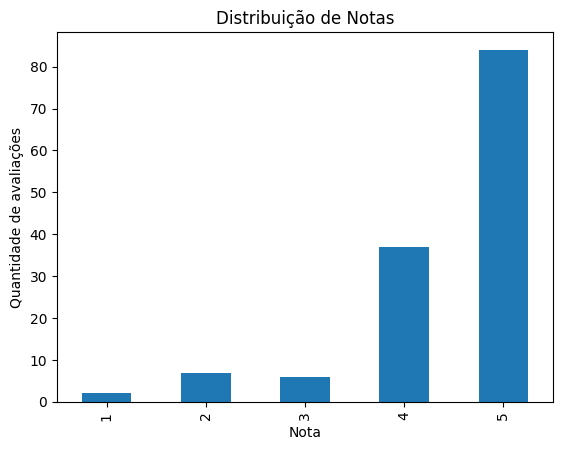

In [50]:
df['Nota'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribuição de Notas")
plt.xlabel("Nota")
plt.ylabel("Quantidade de avaliações")
plt.show()

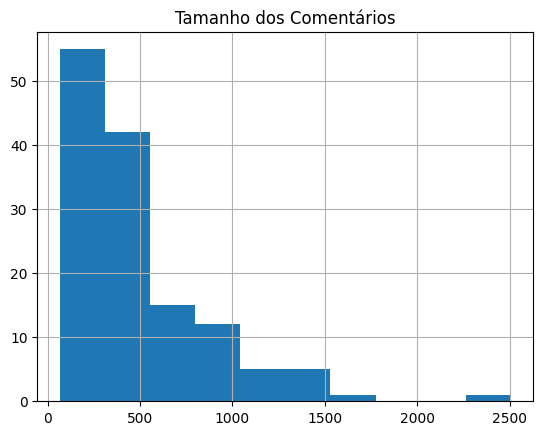

In [57]:
df['tamanho_texto'] = df['Comentario'].apply(len)

df['tamanho_texto'].hist()
plt.title("Tamanho dos Comentários")
plt.show()

In [84]:
import re
from collections import Counter

df['Comentario'] = df['Comentario'].str.lower()

stopwords = [
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas', 'ao', 'à', 'aos', 'às', 'do', 'da', 'dos', 'das', 'no', 'na',
    'nos', 'nas', 'pelo', 'pela', 'pelos', 'pelas', 'eu', 'ele', 'ela', 'nós', 'eles', 'elas', 'me', 'nos', 'meu',
    'minha', 'meus', 'minhas', 'nosso', 'nossa', 'nossos', 'nossas', 'de', 'em', 'por', 'para', 'com', 'sem', 'sob',
    'sobre', 'entre', 'até', 'desde', 'fora', 'e', 'mas', 'ou', 'porque', 'pois', 'que', 'se', 'como', 'quando',
    'também', 'é', 'muito', 'não', 'bem','mais','estava', 'fila', 'são', 'pra', 'já', 'tem', 'foi', 'tudo',
    'sempre', 'pouco', 'você', 'lugar', 'ser', 'vale', 'fui', 'achei', 'pena', 'ir', 'ter', 'pedi', 'só', 'porém', 'quem',
    'comer', 'super', 'outra'
]

todosComentarios = " ".join(df['Comentario'])
todosComentarios = re.sub(r'[^\w\s]', '', todosComentarios)
palavras = todosComentarios.split()
palavras_filtradas = [p for p in palavras if p not in stopwords]

Counter(palavras_filtradas).most_common(20)

[('doces', 61),
 ('café', 53),
 ('cafeteria', 48),
 ('atendimento', 43),
 ('salgados', 42),
 ('opções', 37),
 ('bom', 36),
 ('bebidas', 35),
 ('cheio', 34),
 ('experiência', 34),
 ('ambiente', 34),
 ('liberdade', 33),
 ('comida', 31),
 ('local', 31),
 ('recomendo', 31),
 ('chocolate', 30),
 ('qualidade', 26),
 ('sabor', 25),
 ('semana', 24),
 ('doce', 23)]

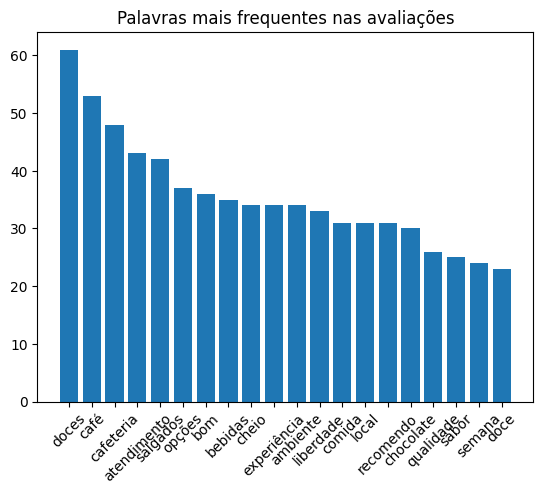

In [91]:
import matplotlib.pyplot as plt

top_palavras = Counter(palavras_filtradas).most_common(20)

palavras = [p[0] for p in top_palavras]
frequencias = [p[1] for p in top_palavras]

plt.bar(palavras, frequencias)
plt.title("Palavras mais frequentes nas avaliações")
plt.xticks(rotation=45)
plt.show()